In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import numpy as np
import matplotlib.pyplot as plt
import pickle

import sys
sys.path.insert(0, '../../../')

from src.difsched.config import getEnvConfig, visualizeEnvConfig
from src.difsched.agents.mdp import MdpKernel
#from src.difsched.agents.Others import PolicyDemoAdaptiveAlpha

Environment Configuration
Environment Type:       HYBRID
Number of Users:        8
Window Length:          200
Dataflow:               thumb_fr
Sigma List:             [0.7, 0.75, 0.8, 0.85, 0.9]
Resource Bar:           4
Bandwidth:              40
Sub Agents:             [[1, 1]]
User Map:               [[0, 1, 2, 3], [4, 5, 6, 7]]


avg_reward_mdpDeter: 0.004752327171360148


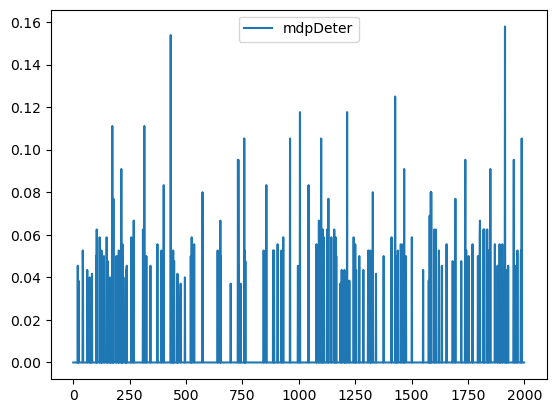

In [6]:
configIdx = 1
envParams = getEnvConfig(configIdx)
visualizeEnvConfig(envParams)

if envParams['EnvType'] == "SPS":
    from src.difsched.env.SPS import createEnv
    from src.difsched.env.SPS import PolicySimulator
else:
    from src.difsched.env.Hybrid import createEnv
    from src.difsched.env.Hybrid import PolicySimulator

trafficDataParentPath =  f'../../../data/processed/traffic'
env = createEnv(envParams, trafficDataParentPath)

obvMode = "predicted"
num_windows = 2000
N_episodes = 10

user_map = envParams['user_map']
policy_map = []
for sub_agents_idx in envParams['sub_agents_idx'][0]:
    with open(f'../../../data/results/MdpPolicy/mdp_config{sub_agents_idx}.pkl', 'rb') as f:
        mdpKernelParams = pickle.load(f)
    mdpPolicy = MdpKernel()
    mdpPolicy.load_policy(mdpKernelParams, policyMode="deterministic", randomR=False)
    policy_map.append(mdpPolicy)

policySimulator = PolicySimulator(env)
policySimulator.setupModes(obvMode=obvMode, mode="test", type="data")

policySimulator.loadPolicies(policy_map, user_map)
simResultMdpDeter = policySimulator.runSimulation(num_windows=num_windows, N_episodes=N_episodes)

print(f"avg_reward_mdpDeter: {np.mean(simResultMdpDeter['rewardRecord'])}")

plt.plot(simResultMdpDeter['rewardRecord'], label="mdpDeter")
plt.legend()
plt.show()